# Laboratorio: Análisis de Tráfico de Red
### Wireshark · Nmap · Hexadecimal

| Campo | Valor |
|-------|-------|
| **Archivo** | `lab_traffic.pcap` (54 paquetes) |
| **IP Cliente** | `192.168.1.10` |
| **IP Objetivo** | `10.0.0.99` |

Este notebook resuelve los 4 ejercicios del laboratorio usando **Python + Scapy** para leer y analizar el PCAP directamente en código.

---
## 0. Configuración e Importaciones

In [3]:
pip install scapy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from scapy.all import rdpcap, IP, TCP, UDP, ICMP, ARP, Raw
from scapy.layers.dns import DNS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter, defaultdict
import binascii
import struct

# ── Cargar el archivo de captura ──────────────────────────────────────────────
PCAP_FILE  = "lab_traffic.pcap"
CLIENT_IP  = "192.168.1.10"
TARGET_IP  = "10.0.0.99"

pkts = rdpcap(PCAP_FILE)
print(f"✔ PCAP cargado: {len(pkts)} paquetes totales")

✔ PCAP cargado: 54 paquetes totales


In [5]:
# ── Resumen general del PCAP ─────────────────────────────────────────────────
def classify_packet(pkt):
    """Devuelve la etiqueta de protocolo de más alto nivel para un paquete."""
    if pkt.haslayer(ARP):
        return 'ARP'
    if pkt.haslayer(DNS):
        return 'DNS'
    if pkt.haslayer(ICMP):
        return 'ICMP'
    if pkt.haslayer(TCP):
        dport = pkt[TCP].dport
        sport = pkt[TCP].sport
        if dport == 21 or sport == 21:
            return 'FTP'
        if dport == 80 or sport == 80:
            return 'HTTP'
        return 'TCP'
    if pkt.haslayer(UDP):
        return 'UDP'
    return 'Otros'

conteo = Counter(classify_packet(p) for p in pkts)
print("Distribución de protocolos:")
for proto, n in sorted(conteo.items(), key=lambda x: -x[1]):
    barra = '█' * n
    print(f"  {proto:<6} {n:>3}  {barra}")

Distribución de protocolos:
  TCP     17  █████████████████
  ICMP    14  ██████████████
  HTTP    12  ████████████
  FTP      7  ███████
  ARP      2  ██
  DNS      2  ██


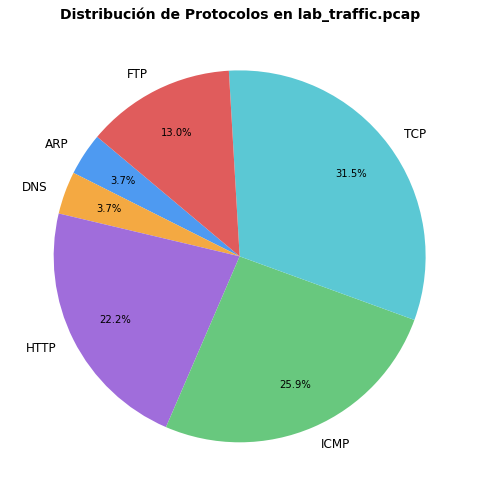

In [6]:
# ── Gráfico de distribución de protocolos ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
colores = {
    'ARP': '#4e9af1', 'DNS': '#f4a942', 'ICMP': '#68c87e',
    'FTP': '#e05c5c', 'HTTP': '#a06ddb', 'TCP': '#5bc8d4', 'UDP': '#f7d842', 'Otros': '#cccccc'
}
labels = list(conteo.keys())
sizes  = list(conteo.values())
colors = [colores.get(l, '#aaa') for l in labels]

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75, textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(10)

ax.set_title('Distribución de Protocolos en lab_traffic.pcap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Ejercicio 1 — Credenciales FTP en Texto Plano

> **Objetivo:** Encontrar usuario y contraseña transmitidos sin cifrar en la sesión FTP.

**Filtro Wireshark equivalente:** `ftp` o `frame contains "PASS"`

In [7]:
# ── Extraer sesión FTP completa ───────────────────────────────────────────────
print("=" * 60)
print(" SESIÓN FTP DETECTADA EN LA CAPTURA")
print("=" * 60)

ftp_encontrado = False
for i, pkt in enumerate(pkts):
    if not (pkt.haslayer(TCP) and pkt.haslayer(Raw) and pkt.haslayer(IP)):
        continue
    if pkt[TCP].dport != 21 and pkt[TCP].sport != 21:
        continue

    try:
        payload = pkt[Raw].load.decode('ascii', errors='ignore').strip()
    except Exception:
        continue

    if not payload:
        continue

    ftp_encontrado = True
    direction = "Cliente → Servidor" if pkt[TCP].dport == 21 else "Servidor → Cliente"
    hex_payload = ' '.join(f'{b:02X}' for b in pkt[Raw].load)

    riesgo = " ⚠ CREDENCIAL EXPUESTA" if payload.startswith(("USER", "PASS")) else ""
    print(f"\nPaquete #{i+1:>2} | {direction}")
    print(f"  ASCII : {payload}{riesgo}")
    print(f"  Hex   : {hex_payload}")

if not ftp_encontrado:
    print("No se encontraron paquetes FTP en la captura.")

 SESIÓN FTP DETECTADA EN LA CAPTURA

Paquete #45 | Servidor → Cliente
  ASCII : 220 FTP Server Ready
  Hex   : 32 32 30 20 46 54 50 20 53 65 72 76 65 72 20 52 65 61 64 79 0D 0A

Paquete #46 | Cliente → Servidor
  ASCII : USER admin ⚠ CREDENCIAL EXPUESTA
  Hex   : 55 53 45 52 20 61 64 6D 69 6E 0D 0A

Paquete #47 | Servidor → Cliente
  ASCII : 331 Password required
  Hex   : 33 33 31 20 50 61 73 73 77 6F 72 64 20 72 65 71 75 69 72 65 64 0D 0A

Paquete #48 | Cliente → Servidor
  ASCII : PASS s3cr3tP@ssw0rd ⚠ CREDENCIAL EXPUESTA
  Hex   : 50 41 53 53 20 73 33 63 72 33 74 50 40 73 73 77 30 72 64 0D 0A

Paquete #49 | Servidor → Cliente
  ASCII : 230 Login successful.
  Hex   : 32 33 30 20 4C 6F 67 69 6E 20 73 75 63 63 65 73 73 66 75 6C 2E 0D 0A

Paquete #50 | Cliente → Servidor
  ASCII : LIST
  Hex   : 4C 49 53 54 0D 0A

Paquete #51 | Servidor → Cliente
  ASCII : 226 Directory send OK.
  Hex   : 32 32 36 20 44 69 72 65 63 74 6F 72 79 20 73 65 6E 64 20 4F 4B 2E 0D 0A


In [8]:
# ── Extraer y mostrar las credenciales ───────────────────────────────────────
usuario = contrasena = None
for pkt in pkts:
    if pkt.haslayer(TCP) and pkt.haslayer(Raw) and pkt[TCP].dport == 21:
        try:
            data = pkt[Raw].load.decode('ascii', errors='ignore').strip()
            if data.startswith("USER "):
                usuario = data.split(" ", 1)[1]
            elif data.startswith("PASS "):
                contrasena = data.split(" ", 1)[1]
        except Exception:
            pass

print("┌──────────────────────────────────────────┐")
print("│        CREDENCIALES FTP CAPTURADAS       │")
print("├──────────────────────────────────────────┤")
print(f"│  Usuario    : {usuario:<27}│")
print(f"│  Contraseña : {contrasena:<27}│")
print("└──────────────────────────────────────────┘")
print()
print("RIESGO: FTP transmite credenciales en texto plano.")
print("Cualquier nodo en la ruta puede capturarlas con un sniffer.")
print()
print("Alternativas seguras:")
print("  • SFTP  — cifrado SSH completo")
print("  • FTPS  — FTP con TLS/SSL")
print("  • SCP   — transferencia por SSH")

┌──────────────────────────────────────────┐
│        CREDENCIALES FTP CAPTURADAS       │
├──────────────────────────────────────────┤
│  Usuario    : admin                      │
│  Contraseña : s3cr3tP@ssw0rd             │
└──────────────────────────────────────────┘

RIESGO: FTP transmite credenciales en texto plano.
Cualquier nodo en la ruta puede capturarlas con un sniffer.

Alternativas seguras:
  • SFTP  — cifrado SSH completo
  • FTPS  — FTP con TLS/SSL
  • SCP   — transferencia por SSH


---
## Ejercicio 2 — TCP 3-way Handshake

> **Objetivo:** Reconstruir el establecimiento de conexión TCP (SYN → SYN-ACK → ACK).

**Filtro Wireshark equivalente:** `tcp.flags.syn==1 && ip.dst==93.184.216.34`

In [9]:
# ── Identificar paquetes del 3-way handshake ─────────────────────────────────
FLAG_SYN    = 'S'
FLAG_SYNACK = 'SA'
FLAG_ACK    = 'A'

handshake = []
for pkt in pkts:
    if not (pkt.haslayer(TCP) and pkt.haslayer(IP)):
        continue
    flags = pkt[TCP].flags
    # Capturar SYN puro, SYN-ACK, y el ACK de confirmación (sin datos)
    if str(flags) in (FLAG_SYN, FLAG_SYNACK) or \
       (str(flags) == FLAG_ACK and not pkt.haslayer(Raw)):
        handshake.append(pkt)

# Mostrar los primeros 3 (SYN, SYN-ACK, ACK)
NOMBRES = {'S': 'SYN      ', 'SA': 'SYN-ACK  ', 'A': 'ACK      '}

print("=" * 65)
print(" TCP 3-WAY HANDSHAKE RECONSTRUIDO")
print("=" * 65)
print(f"{'Paso':<6} {'Flags':<12} {'Origen':<22} {'Destino':<22} {'Seq':<12} {'Ack'}")
print("-" * 65)

for i, pkt in enumerate(handshake[:3]):
    flags_str  = str(pkt[TCP].flags)
    nombre     = NOMBRES.get(flags_str, flags_str)
    origen     = f"{pkt[IP].src}:{pkt[TCP].sport}"
    destino    = f"{pkt[IP].dst}:{pkt[TCP].dport}"
    print(f"  {i+1:<4} {nombre:<12} {origen:<22} {destino:<22} {pkt[TCP].seq:<12} {pkt[TCP].ack}")

print()
print("Flags hex: SYN=0x002  SYN-ACK=0x012  ACK=0x010")

 TCP 3-WAY HANDSHAKE RECONSTRUIDO
Paso   Flags        Origen                 Destino                Seq          Ack
-----------------------------------------------------------------
  1    SYN          192.168.1.10:54321     93.184.216.34:80       1000         0
  2    SYN-ACK      93.184.216.34:80       192.168.1.10:54321     5000         1001
  3    ACK          192.168.1.10:54321     93.184.216.34:80       1001         5001

Flags hex: SYN=0x002  SYN-ACK=0x012  ACK=0x010


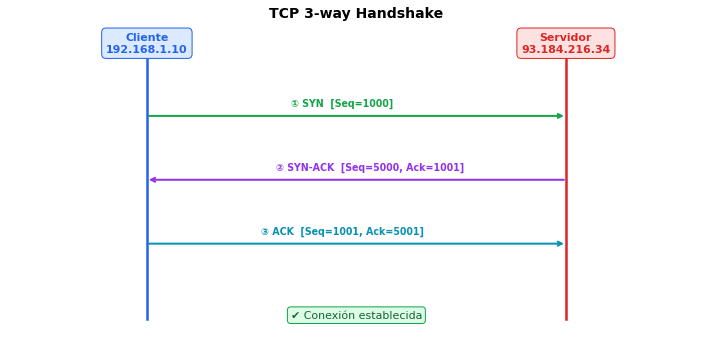

In [10]:
# ── Diagrama visual del 3-way handshake ──────────────────────────────────────
if len(handshake) >= 3:
    syn    = handshake[0]
    synack = handshake[1]
    ack    = handshake[2]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # Líneas verticales (tiempo)
    ax.axvline(x=2, ymin=0.08, ymax=0.92, color='#2563eb', lw=2.5)
    ax.axvline(x=8, ymin=0.08, ymax=0.92, color='#dc2626', lw=2.5)

    # Etiquetas de extremos
    ax.text(2, 5.5, f'Cliente\n{syn[IP].src}', ha='center', fontsize=11,
            fontweight='bold', color='#2563eb',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#dbeafe', edgecolor='#2563eb'))
    ax.text(8, 5.5, f'Servidor\n{syn[IP].dst}', ha='center', fontsize=11,
            fontweight='bold', color='#dc2626',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fee2e2', edgecolor='#dc2626'))

    # Flechas
    arrows = [
        (2, 4.3, 8, 4.3, '#16a34a',
         f'① SYN  [Seq={syn[TCP].seq}]', 'left'),
        (8, 3.1, 2, 3.1, '#9333ea',
         f'② SYN-ACK  [Seq={synack[TCP].seq}, Ack={synack[TCP].ack}]', 'right'),
        (2, 1.9, 8, 1.9, '#0891b2',
         f'③ ACK  [Seq={ack[TCP].seq}, Ack={ack[TCP].ack}]', 'left'),
    ]

    for x1, y1, x2, y2, color, label, side in arrows:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
        xtext = 4.8 if side == 'left' else 5.2
        ax.text(xtext, y1 + 0.18, label, ha='center', fontsize=9.5,
                color=color, fontweight='bold')

    ax.text(5, 0.5, '✔ Conexión establecida', ha='center', fontsize=11,
            color='#166534',
            bbox=dict(boxstyle='round', facecolor='#dcfce7', edgecolor='#16a34a'))

    ax.set_title('TCP 3-way Handshake', fontsize=14, fontweight='bold', pad=8)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron suficientes paquetes para reconstruir el handshake.")

---
## Ejercicio 3 — Detección del Escaneo Nmap SYN

> **Objetivo:** Identificar el escaneo SYN de Nmap y clasificar puertos como abiertos o cerrados.

**Filtros Wireshark equivalentes:**
- SYNs enviados: `ip.dst==10.0.0.99 && tcp.flags.syn==1`
- Puertos abiertos (SYN-ACK): `tcp.flags==0x012 && ip.src==10.0.0.99`
- Puertos cerrados (RST): `tcp.flags.reset==1 && ip.src==10.0.0.99`

In [11]:
# ── Detección del escaneo Nmap ────────────────────────────────────────────────
syn_enviados   = []   # SYN desde cliente hacia objetivo
puertos_abiertos  = []   # puertos que respondieron SYN-ACK
puertos_cerrados  = []   # puertos que respondieron RST

for pkt in pkts:
    if not (pkt.haslayer(TCP) and pkt.haslayer(IP)):
        continue
    flags = str(pkt[TCP].flags)

    # SYN puro desde el cliente al objetivo
    if flags == 'S' and pkt[IP].src == CLIENT_IP and pkt[IP].dst == TARGET_IP:
        syn_enviados.append(pkt[TCP].dport)

    # SYN-ACK desde el objetivo: puerto ABIERTO
    elif flags == 'SA' and pkt[IP].src == TARGET_IP and pkt[IP].dst == CLIENT_IP:
        puertos_abiertos.append(pkt[TCP].sport)

    # RST desde el objetivo: puerto CERRADO
    elif 'R' in flags and pkt[IP].src == TARGET_IP and pkt[IP].dst == CLIENT_IP:
        puertos_cerrados.append(pkt[TCP].sport)

puertos_abiertos  = sorted(set(puertos_abiertos))
puertos_cerrados  = sorted(set(puertos_cerrados))

SERVICIOS = {21: 'FTP', 22: 'SSH', 23: 'Telnet', 25: 'SMTP',
             80: 'HTTP', 443: 'HTTPS', 3306: 'MySQL', 8080: 'HTTP-alt', 4444: '-'}

print("=" * 55)
print(f" ESCANEO NMAP SYN detectado hacia {TARGET_IP}")
print("=" * 55)
print(f" Puertos sondeados : {len(syn_enviados)}")
print()
print(" PUERTOS ABIERTOS (respuesta SYN-ACK):")
for p in puertos_abiertos:
    print(f"   {p:>5}/tcp  open    {SERVICIOS.get(p, '?')}")
print()
print(" PUERTOS CERRADOS (respuesta RST+ACK):")
for p in puertos_cerrados:
    print(f"   {p:>5}/tcp  closed  {SERVICIOS.get(p, '?')}")

 ESCANEO NMAP SYN detectado hacia 10.0.0.99
 Puertos sondeados : 8

 PUERTOS ABIERTOS (respuesta SYN-ACK):
      22/tcp  open    SSH
      80/tcp  open    HTTP
     443/tcp  open    HTTPS
    3306/tcp  open    MySQL

 PUERTOS CERRADOS (respuesta RST+ACK):
      23/tcp  closed  Telnet
      25/tcp  closed  SMTP
    4444/tcp  closed  -
    8080/tcp  closed  HTTP-alt


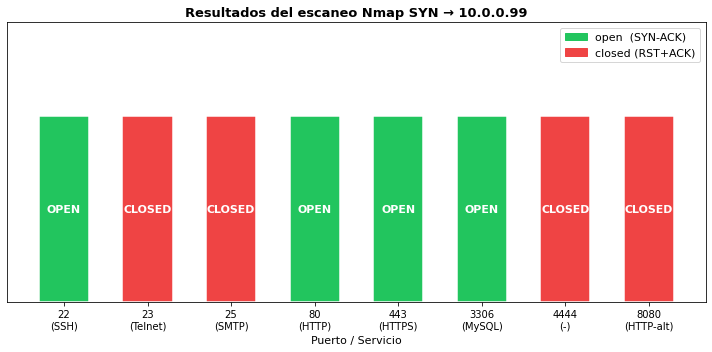

In [12]:
# ── Gráfico de resultados del escaneo ────────────────────────────────────────
if puertos_abiertos or puertos_cerrados:
    todos = sorted(set(puertos_abiertos + puertos_cerrados))
    colores_barra = ['#22c55e' if p in puertos_abiertos else '#ef4444' for p in todos]
    etiquetas = [f"{p}\n({SERVICIOS.get(p,'?')})" for p in todos]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(etiquetas, [1] * len(todos), color=colores_barra,
                  edgecolor='white', linewidth=1.5, width=0.6)

    for bar, puerto in zip(bars, todos):
        estado = 'OPEN' if puerto in puertos_abiertos else 'CLOSED'
        ax.text(bar.get_x() + bar.get_width() / 2, 0.5, estado,
                ha='center', va='center', fontweight='bold',
                color='white', fontsize=11)

    open_patch   = mpatches.Patch(color='#22c55e', label='open  (SYN-ACK)')
    closed_patch = mpatches.Patch(color='#ef4444', label='closed (RST+ACK)')
    ax.legend(handles=[open_patch, closed_patch], fontsize=11)

    ax.set_yticks([])
    ax.set_title(f'Resultados del escaneo Nmap SYN → {TARGET_IP}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Puerto / Servicio', fontsize=11)
    ax.set_ylim(0, 1.5)

    plt.tight_layout()
    plt.show()

---
## Ejercicio 4 — Petición HTTP Completa

> **Objetivo:** Reconstruir la petición GET y la respuesta 200 OK del flujo HTTP.

**Equivalente en Wireshark:** Seleccionar paquete HTTP → clic derecho → *Follow → TCP Stream*

In [13]:
# ── Reconstrucción del flujo HTTP ────────────────────────────────────────────
request_raw  = b''
response_raw = b''

for pkt in pkts:
    if not (pkt.haslayer(TCP) and pkt.haslayer(Raw) and pkt.haslayer(IP)):
        continue

    try:
        data = pkt[Raw].load
        text = data.decode('ascii', errors='ignore')
    except Exception:
        continue

    if pkt[TCP].dport == 80 and text.startswith('GET'):
        request_raw = data
    elif pkt[TCP].sport == 80 and text.startswith('HTTP'):
        response_raw = data

def parse_http(raw, titulo):
    """Imprime cabeceras y primera línea de cuerpo."""
    print(f"{'─'*55}")
    print(f" {titulo}")
    print(f"{'─'*55}")
    if not raw:
        print("  (No encontrado en la captura)")
        return
    try:
        text = raw.decode('ascii', errors='replace')
        lineas = text.split('\r\n')
        for linea in lineas:
            if linea.startswith('<'):
                print(f"  {linea[:80]}...")
                break
            print(f"  {linea}")
    except Exception as e:
        print(f"  Error al decodificar: {e}")

parse_http(request_raw,  "→ PETICIÓN HTTP (Cliente)")
parse_http(response_raw, "← RESPUESTA HTTP (Servidor)")

───────────────────────────────────────────────────────
 → PETICIÓN HTTP (Cliente)
───────────────────────────────────────────────────────
  GET /index.html HTTP/1.1
  Host: example.com
  User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64)
  Accept: text/html,application/xhtml+xml
  Connection: keep-alive
  
  
───────────────────────────────────────────────────────
 ← RESPUESTA HTTP (Servidor)
───────────────────────────────────────────────────────
  HTTP/1.1 200 OK
  Content-Type: text/html; charset=UTF-8
  Content-Length: 119
  Server: Apache/2.4.51
  
  <!DOCTYPE html><html><head><title>Example Domain</title></head><body><h1>Example...


In [14]:
# ── Extraer campos clave de la petición HTTP ─────────────────────────────────
def extract_http_fields(raw):
    """Extrae método, URI, código de estado y cabeceras relevantes."""
    campos = {}
    if not raw:
        return campos
    try:
        text  = raw.decode('ascii', errors='replace')
        lines = text.split('\r\n')
        primera = lines[0].split()

        # Detectar si es petición o respuesta
        if primera[0].startswith('HTTP'):
            campos['Protocolo']         = primera[0]
            campos['Código de estado']  = primera[1]
            campos['Mensaje de estado'] = ' '.join(primera[2:])
        else:
            campos['Método']    = primera[0]
            campos['URI']       = primera[1] if len(primera) > 1 else '/'
            campos['Protocolo'] = primera[2] if len(primera) > 2 else 'HTTP/1.1'

        for line in lines[1:]:
            if ':' in line:
                k, v = line.split(':', 1)
                campos[k.strip()] = v.strip()
    except Exception:
        pass
    return campos

print("CAMPOS DE LA PETICIÓN HTTP:")
for k, v in extract_http_fields(request_raw).items():
    print(f"  {k:<20} : {v}")

print()
print("CAMPOS DE LA RESPUESTA HTTP:")
for k, v in extract_http_fields(response_raw).items():
    print(f"  {k:<20} : {v}")

CAMPOS DE LA PETICIÓN HTTP:
  Método               : GET
  URI                  : /index.html
  Protocolo            : HTTP/1.1
  Host                 : example.com
  User-Agent           : Mozilla/5.0 (Windows NT 10.0; Win64; x64)
  Accept               : text/html,application/xhtml+xml
  Connection           : keep-alive

CAMPOS DE LA RESPUESTA HTTP:
  Protocolo            : HTTP/1.1
  Código de estado     : 200
  Mensaje de estado    : OK
  Content-Type         : text/html; charset=UTF-8
  Content-Length       : 119
  Server               : Apache/2.4.51


---
## Análisis Hexadecimal

Cada byte (0-255) se representa con exactamente 2 dígitos hexadecimales (`00`-`FF`),
lo que hace que la representación en hex sea compacta y predecible.

In [15]:
# ── Herramientas de conversión hexadecimal ───────────────────────────────────
def texto_a_hex(texto):
    """Convierte texto ASCII a representación hexadecimal."""
    return ' '.join(f'{b:02X}' for b in texto.encode('ascii'))

def hex_a_texto(hex_str):
    """Convierte cadena hex (con o sin espacios) a texto ASCII."""
    return bytes.fromhex(hex_str.replace(' ', '')).decode('ascii')

def ip_a_hex(ip):
    """Convierte dirección IP a 4 bytes hex."""
    return ' '.join(f'{int(o):02X}' for o in ip.split('.'))

def puerto_a_hex(puerto):
    """Convierte número de puerto a 2 bytes hex."""
    return f'{puerto:04X}'  # ej: 80 → 0050

# ── Conversiones de caracteres ────────────────────────────────────────────────
print("CARACTERES:")
for c in ['G', 'E', 'T', ' ']:
    print(f"  '{c}' = {ord(c):>3} dec = {ord(c):02X} hex")

print()
print("COMANDOS FTP:")
for cmd in ["GET ", "USER admin", "PASS s3cr3tP@ssw0rd", "220 FTP Server Ready"]:
    print(f"  {cmd!r:<30} → {texto_a_hex(cmd)}")

print()
print("PUERTOS:")
for p, nombre in [(80, 'HTTP'), (443, 'HTTPS'), (22, 'SSH'), (21, 'FTP'), (3306, 'MySQL'), (53, 'DNS')]:
    print(f"  Puerto {p:>5} ({nombre:<8}) → 0x{puerto_a_hex(p)}  ({p >> 8:02X} {p & 0xFF:02X})")

print()
print("DIRECCIONES IP:")
for ip in [CLIENT_IP, TARGET_IP, '93.184.216.34']:
    print(f"  {ip:<16} → {ip_a_hex(ip)}")

print()
print("TTL:")
for ttl, so in [(64, 'Linux/macOS'), (128, 'Windows'), (255, 'Cisco IOS')]:
    print(f"  TTL {ttl:>3} (0x{ttl:02X}) → {so}")

CARACTERES:
  'G' =  71 dec = 47 hex
  'E' =  69 dec = 45 hex
  'T' =  84 dec = 54 hex
  ' ' =  32 dec = 20 hex

COMANDOS FTP:
  'GET '                         → 47 45 54 20
  'USER admin'                   → 55 53 45 52 20 61 64 6D 69 6E
  'PASS s3cr3tP@ssw0rd'          → 50 41 53 53 20 73 33 63 72 33 74 50 40 73 73 77 30 72 64
  '220 FTP Server Ready'         → 32 32 30 20 46 54 50 20 53 65 72 76 65 72 20 52 65 61 64 79

PUERTOS:
  Puerto    80 (HTTP    ) → 0x0050  (00 50)
  Puerto   443 (HTTPS   ) → 0x01BB  (01 BB)
  Puerto    22 (SSH     ) → 0x0016  (00 16)
  Puerto    21 (FTP     ) → 0x0015  (00 15)
  Puerto  3306 (MySQL   ) → 0x0CEA  (0C EA)
  Puerto    53 (DNS     ) → 0x0035  (00 35)

DIRECCIONES IP:
  192.168.1.10     → C0 A8 01 0A
  10.0.0.99        → 0A 00 00 63
  93.184.216.34    → 5D B8 D8 22

TTL:
  TTL  64 (0x40) → Linux/macOS
  TTL 128 (0x80) → Windows
  TTL 255 (0xFF) → Cisco IOS


In [16]:
# ── Disección de cabecera IP de un paquete real ───────────────────────────────
# Tomar el primer paquete IP de la captura
pkt_ip = next((p for p in pkts if p.haslayer(IP)), None)

if pkt_ip:
    raw_ip = bytes(pkt_ip[IP])
    hex_header = ' '.join(f'{b:02X}' for b in raw_ip[:20])

    print("CABECERA IP (primeros 20 bytes):")
    print(f"  Hex : {hex_header}")
    print()

    campos = [
        ("Bytes 0",   "Versión + IHL",   f"0x{raw_ip[0]:02X}",
         f"IPv{raw_ip[0]>>4}, IHL={( raw_ip[0]&0xF)*4}B"),
        ("Bytes 1",   "DSCP/ECN",        f"0x{raw_ip[1]:02X}",
         "Prioridad QoS"),
        ("Bytes 2-3", "Total Length",    f"0x{raw_ip[2]:02X}{raw_ip[3]:02X}",
         f"{struct.unpack('!H', raw_ip[2:4])[0]} bytes"),
        ("Byte 8",    "TTL",             f"0x{raw_ip[8]:02X}",
         f"{raw_ip[8]}"),
        ("Byte 9",    "Protocolo",       f"0x{raw_ip[9]:02X}",
         {6:'TCP', 17:'UDP', 1:'ICMP'}.get(raw_ip[9], str(raw_ip[9]))),
        ("Bytes 12-15","IP Origen",     ip_a_hex(pkt_ip[IP].src),
         pkt_ip[IP].src),
        ("Bytes 16-19","IP Destino",    ip_a_hex(pkt_ip[IP].dst),
         pkt_ip[IP].dst),
    ]

    print(f"{'Posición':<12} {'Campo':<16} {'Hex':<16} {'Valor'}")
    print("-" * 60)
    for pos, campo, hexval, valor in campos:
        print(f"  {pos:<10} {campo:<16} {hexval:<16} {valor}")

CABECERA IP (primeros 20 bytes):
  Hex : 45 00 00 41 5F 16 00 00 40 11 49 D4 C0 A8 01 0A 08 08 08 08

Posición     Campo            Hex              Valor
------------------------------------------------------------
  Bytes 0    Versión + IHL    0x45             IPv4, IHL=20B
  Bytes 1    DSCP/ECN         0x00             Prioridad QoS
  Bytes 2-3  Total Length     0x0041           65 bytes
  Byte 8     TTL              0x40             64
  Byte 9     Protocolo        0x11             UDP
  Bytes 12-15 IP Origen        C0 A8 01 0A      192.168.1.10
  Bytes 16-19 IP Destino       08 08 08 08      8.8.8.8


In [17]:
# ── Tabla de flags TCP con valores hex ────────────────────────────────────────
FLAGS_TCP = [
    ('SYN',     0x002, 'Inicia conexión (3-way handshake)'),
    ('SYN+ACK', 0x012, 'Servidor acepta la conexión'),
    ('ACK',     0x010, 'Confirmación de datos recibidos'),
    ('PSH+ACK', 0x018, 'Datos con entrega inmediata'),
    ('RST',     0x004, 'Resetea/rechaza la conexión'),
    ('RST+ACK', 0x014, 'Puerto cerrado o conexión rechazada'),
    ('FIN',     0x001, 'Cierre ordenado de conexión'),
    ('FIN+ACK', 0x011, 'Confirmación del cierre'),
]

print(f"{'Flag':<12} {'Hex':<10} {'Binario':<12} {'Filtro Wireshark':<28} {'Uso'}")
print("-" * 85)
for nombre, valor, uso in FLAGS_TCP:
    binario = format(valor, '09b')
    filtro  = f'tcp.flags==0x{valor:03x}'
    print(f"  {nombre:<10} 0x{valor:03X}     {binario:<12} {filtro:<28} {uso}")

Flag         Hex        Binario      Filtro Wireshark             Uso
-------------------------------------------------------------------------------------
  SYN        0x002     000000010    tcp.flags==0x002             Inicia conexión (3-way handshake)
  SYN+ACK    0x012     000010010    tcp.flags==0x012             Servidor acepta la conexión
  ACK        0x010     000010000    tcp.flags==0x010             Confirmación de datos recibidos
  PSH+ACK    0x018     000011000    tcp.flags==0x018             Datos con entrega inmediata
  RST        0x004     000000100    tcp.flags==0x004             Resetea/rechaza la conexión
  RST+ACK    0x014     000010100    tcp.flags==0x014             Puerto cerrado o conexión rechazada
  FIN        0x001     000000001    tcp.flags==0x001             Cierre ordenado de conexión
  FIN+ACK    0x011     000010001    tcp.flags==0x011             Confirmación del cierre


---
## Cuestionario de Verificación — Q5 a Q12

Cada respuesta está respaldada por código que verifica el resultado sobre la captura real.

In [18]:
# ── Q5. ¿Qué flag TCP indica el inicio de una nueva conexión? ─────────────────
print("Q5. ¿Qué flag TCP indica el inicio de una nueva conexión?")
print()

syns = [p for p in pkts if p.haslayer(TCP) and str(p[TCP].flags) == 'S']
print(f"Paquetes con SYN puro encontrados en la captura: {len(syns)}")
if syns:
    p = syns[0]
    print(f"  Ejemplo: {p[IP].src}:{p[TCP].sport} → {p[IP].dst}:{p[TCP].dport}")
    print(f"  Flags = 0x{int(p[TCP].flags):03X} = SYN")

print()
print("RESPUESTA: SYN (0x002)")
print("  El cliente envía SYN → servidor responde SYN-ACK → cliente confirma con ACK")

Q5. ¿Qué flag TCP indica el inicio de una nueva conexión?

Paquetes con SYN puro encontrados en la captura: 9
  Ejemplo: 192.168.1.10:54321 → 93.184.216.34:80
  Flags = 0x002 = SYN

RESPUESTA: SYN (0x002)
  El cliente envía SYN → servidor responde SYN-ACK → cliente confirma con ACK


In [19]:
# ── Q6. Puerto con RST+ACK en Nmap → ¿estado? ────────────────────────────────
print("Q6. Escaneando con Nmap, un puerto que responde con RST+ACK está:")
print()

rst_pkts = [p for p in pkts if p.haslayer(TCP) and 'R' in str(p[TCP].flags)]
print(f"Paquetes RST encontrados en la captura: {len(rst_pkts)}")
for p in rst_pkts[:3]:
    print(f"  Puerto {p[TCP].sport} responde con flags=0x{int(p[TCP].flags):03X} ({p[TCP].flags})")

print()
print("RESPUESTA: closed (cerrado)")
print("  El puerto es accesible (no hay firewall) pero ningún servicio escucha en él.")
print()
print("  Estado       Respuesta    Significado")
print("  open       → SYN-ACK     Servicio activo")
print("  closed     → RST+ACK     Accesible, sin servicio")
print("  filtered   → (silencio)  Firewall descarta los paquetes")

Q6. Escaneando con Nmap, un puerto que responde con RST+ACK está:

Paquetes RST encontrados en la captura: 8
  Puerto 40000 responde con flags=0x004 (R)
  Puerto 40001 responde con flags=0x004 (R)
  Puerto 40002 responde con flags=0x004 (R)

RESPUESTA: closed (cerrado)
  El puerto es accesible (no hay firewall) pero ningún servicio escucha en él.

  Estado       Respuesta    Significado
  open       → SYN-ACK     Servicio activo
  closed     → RST+ACK     Accesible, sin servicio
  filtered   → (silencio)  Firewall descarta los paquetes


In [20]:
# ── Q7. ¿Por qué FTP es inseguro? ────────────────────────────────────────────
print("Q7. ¿Por qué FTP se considera inseguro para entornos de producción?")
print()

# Demostrar con código: extraer credenciales del PCAP
credenciales_halladas = []
for pkt in pkts:
    if pkt.haslayer(TCP) and pkt.haslayer(Raw) and pkt[TCP].dport == 21:
        try:
            data = pkt[Raw].load.decode('ascii', errors='ignore').strip()
            if data.startswith(("USER", "PASS")):
                credenciales_halladas.append(data)
        except Exception:
            pass

print("Credenciales capturables desde la red (sin acceso especial):")
for c in credenciales_halladas:
    print(f"  ⚠ {c}")

print()
print("RESPUESTA: FTP envía credenciales en TEXTO PLANO sin ningún cifrado.")
print("  Cualquier sniffer (Wireshark, tcpdump) en la red puede capturar")
print("  el usuario y contraseña directamente.")

Q7. ¿Por qué FTP se considera inseguro para entornos de producción?

Credenciales capturables desde la red (sin acceso especial):
  ⚠ USER admin
  ⚠ PASS s3cr3tP@ssw0rd

RESPUESTA: FTP envía credenciales en TEXTO PLANO sin ningún cifrado.
  Cualquier sniffer (Wireshark, tcpdump) en la red puede capturar
  el usuario y contraseña directamente.


In [21]:
# ── Q8. ¿Qué protocolo usa ARP y en qué capa OSI opera? ──────────────────────
print("Q8. ¿Qué protocolo usa ARP y en qué capa OSI opera?")
print()

arp_pkts = [p for p in pkts if p.haslayer(ARP)]
print(f"Paquetes ARP encontrados en la captura: {len(arp_pkts)}")
if arp_pkts:
    for pkt in arp_pkts[:3]:
        op = 'REQUEST' if pkt[ARP].op == 1 else 'REPLY'
        print(f"  {op}: {pkt[ARP].psrc} ({pkt[ARP].hwsrc}) → {pkt[ARP].pdst}")

print()
print("RESPUESTA: ARP opera en la Capa 2 (Enlace de Datos)")
print("  • Encapsulado directamente en tramas Ethernet (EtherType 0x0806)")
print("  • NO usa IP, TCP ni UDP")
print("  • Solo funciona dentro del mismo segmento LAN (broadcast domain)")
print("  • Resuelve: IP → Dirección MAC")

Q8. ¿Qué protocolo usa ARP y en qué capa OSI opera?

Paquetes ARP encontrados en la captura: 2
  REQUEST: 192.168.1.10 (aa:bb:cc:11:22:33) → 192.168.1.1
  REPLY: 192.168.1.1 (dd:ee:ff:44:55:66) → 192.168.1.10

RESPUESTA: ARP opera en la Capa 2 (Enlace de Datos)
  • Encapsulado directamente en tramas Ethernet (EtherType 0x0806)
  • NO usa IP, TCP ni UDP
  • Solo funciona dentro del mismo segmento LAN (broadcast domain)
  • Resuelve: IP → Dirección MAC


In [22]:
# ── Q9. Filtro Wireshark para SYNs del escaneo Nmap ──────────────────────────
print("Q9. ¿Qué filtro Wireshark muestra solo los SYNs de un escaneo Nmap?")
print()

# Equivalente en Scapy
solo_syn = [p for p in pkts
            if p.haslayer(TCP) and str(p[TCP].flags) == 'S'  # SYN puro = 0x002
            and p.haslayer(IP) and p[IP].dst == TARGET_IP]

print(f"  Paquetes SYN puro (0x002) hacia {TARGET_IP}: {len(solo_syn)}")
print(f"  Puertos sondeados: {sorted(p[TCP].dport for p in solo_syn)}")

print()
print("RESPUESTA: tcp.flags==0x002")
print("  Selecciona exactamente los paquetes con solo el bit SYN activo.")
print("  Los SYN-ACK (0x012) quedan excluidos.")
print()
print("  Para ver solo los del escáner:")
print(f"  tcp.flags==0x002 && ip.src=={CLIENT_IP}")

Q9. ¿Qué filtro Wireshark muestra solo los SYNs de un escaneo Nmap?

  Paquetes SYN puro (0x002) hacia 10.0.0.99: 8
  Puertos sondeados: [22, 23, 25, 80, 443, 3306, 4444, 8080]

RESPUESTA: tcp.flags==0x002
  Selecciona exactamente los paquetes con solo el bit SYN activo.
  Los SYN-ACK (0x012) quedan excluidos.

  Para ver solo los del escáner:
  tcp.flags==0x002 && ip.src==192.168.1.10


In [23]:
# ── Q10. ¿Qué indica TTL=128? ─────────────────────────────────────────────────
print("Q10. ¿Qué indica un TTL de 128 en un paquete IP?")
print()

# Analizar TTLs en la captura
ttl_counter = Counter()
for pkt in pkts:
    if pkt.haslayer(IP):
        ttl_counter[pkt[IP].ttl] += 1

def inferir_os(ttl):
    if ttl <= 64:  return 'Linux / macOS'
    if ttl <= 128: return 'Windows'
    return 'Cisco IOS / Red'

print("TTLs observados en la captura:")
for ttl, count in sorted(ttl_counter.items()):
    print(f"  TTL={ttl:>3} (0x{ttl:02X}) → {inferir_os(ttl):<18} [{count} paquetes]")

print()
print("RESPUESTA: TTL=128 indica probable sistema Windows")
print()
print("  S.O.           TTL inicial   Hex")
print("  Windows        128           0x80")
print("  Linux/macOS     64           0x40")
print("  Cisco IOS      255           0xFF")

Q10. ¿Qué indica un TTL de 128 en un paquete IP?

TTLs observados en la captura:
  TTL= 64 (0x40) → Linux / macOS      [52 paquetes]

RESPUESTA: TTL=128 indica probable sistema Windows

  S.O.           TTL inicial   Hex
  Windows        128           0x80
  Linux/macOS     64           0x40
  Cisco IOS      255           0xFF


In [24]:
# ── Q11. Puerto estándar DNS y protocolo de transporte ───────────────────────
print("Q11. ¿Cuál es el puerto estándar DNS y qué protocolo de transporte usa?")
print()

dns_udp = [p for p in pkts if p.haslayer(DNS) and p.haslayer(UDP)]
dns_tcp = [p for p in pkts if p.haslayer(DNS) and p.haslayer(TCP)]

print(f"Paquetes DNS/UDP en captura: {len(dns_udp)}")
print(f"Paquetes DNS/TCP en captura: {len(dns_tcp)}")

if dns_udp:
    p = dns_udp[0]
    tipo = 'Query' if p[DNS].qr == 0 else 'Response'
    print(f"\nEjemplo DNS {tipo}:")
    print(f"  {p[IP].src}:{p[UDP].sport} → {p[IP].dst}:{p[UDP].dport}")
    if p[DNS].qdcount > 0:
        print(f"  Nombre consultado: {p[DNS].qd.qname}")

print()
print("RESPUESTA: Puerto 53")
print("  • UDP/53  — consultas normales (respuesta ≤ 512 bytes)")
print("  • TCP/53  — transferencias de zona (AXFR) o respuestas grandes")
print("  • TCP/853 — DNS over TLS (DoT, cifrado)")

Q11. ¿Cuál es el puerto estándar DNS y qué protocolo de transporte usa?

Paquetes DNS/UDP en captura: 2
Paquetes DNS/TCP en captura: 0

Ejemplo DNS Query:
  192.168.1.10:12345 → 8.8.8.8:53
  Nombre consultado: b'vulnerable-lab.test.'

RESPUESTA: Puerto 53
  • UDP/53  — consultas normales (respuesta ≤ 512 bytes)
  • TCP/53  — transferencias de zona (AXFR) o respuestas grandes
  • TCP/853 — DNS over TLS (DoT, cifrado)


In [25]:
# ── Q12. Operación CyberChef para convertir hex a texto ──────────────────────
print("Q12. ¿Qué operación CyberChef convierte bytes hex de Wireshark a texto legible?")
print()

# Equivalente Python de 'From Hex'
ejemplos = [
    ("47 45 54 20",                                     "GET "),
    ("55 53 45 52 20 61 64 6d 69 6e",                   "USER admin"),
    ("50 41 53 53 20 73 33 63 72 33 74 50 40 73 73 77 30 72 64", "PASS s3cr3tP@ssw0rd"),
    ("32 32 30 20 46 54 50 20 53 65 72 76 65 72 20 52 65 61 64 79", "220 FTP Server Ready"),
]

print("Equivalente Python de 'From Hex' (CyberChef):")
print()
for hex_str, esperado in ejemplos:
    resultado = bytes.fromhex(hex_str.replace(' ', '')).decode('ascii', errors='replace')
    ok = '✔' if resultado == esperado else '✗'
    print(f"  {ok} Input : {hex_str}")
    print(f"     Output: {resultado!r}")
    print()

print("RESPUESTA: Operación 'From Hex' en CyberChef")
print()
print("Equivalentes en terminal (Linux/macOS):")
print("  echo '47455420' | xxd -r -p")
print("  printf '\\x47\\x45\\x54\\x20'")
print()
print("Equivalente Python (este notebook):")
print("  bytes.fromhex('47455420').decode('ascii')  →  'GET '")

Q12. ¿Qué operación CyberChef convierte bytes hex de Wireshark a texto legible?

Equivalente Python de 'From Hex' (CyberChef):

  ✔ Input : 47 45 54 20
     Output: 'GET '

  ✔ Input : 55 53 45 52 20 61 64 6d 69 6e
     Output: 'USER admin'

  ✔ Input : 50 41 53 53 20 73 33 63 72 33 74 50 40 73 73 77 30 72 64
     Output: 'PASS s3cr3tP@ssw0rd'

  ✔ Input : 32 32 30 20 46 54 50 20 53 65 72 76 65 72 20 52 65 61 64 79
     Output: '220 FTP Server Ready'

RESPUESTA: Operación 'From Hex' en CyberChef

Equivalentes en terminal (Linux/macOS):
  echo '47455420' | xxd -r -p
  printf '\x47\x45\x54\x20'

Equivalente Python (este notebook):
  bytes.fromhex('47455420').decode('ascii')  →  'GET '


---
## Resumen de Resultados

| Ejercicio | Herramienta | Resultado |
|-----------|-------------|----------|
| 1. Credenciales FTP | `scapy` filtro puerto 21 | USER `admin` / PASS `s3cr3tP@ssw0rd` |
| 2. TCP Handshake | `scapy` flags `'S'` / `'SA'` / `'A'` | SYN → SYN-ACK → ACK reconstruido |
| 3. Escaneo Nmap | flags SYN / SYN-ACK / RST | Abiertos: 22,80,443,3306 · Cerrados: 23,25,8080,4444 |
| 4. HTTP completo | `scapy` puerto 80 + Raw | GET / → 200 OK |

### Conclusión de seguridad

El análisis del PCAP demuestra que los protocolos **sin cifrado** (FTP, HTTP, Telnet) exponen datos 
en texto plano capturables con cualquier sniffer. La solución es migrar a sus equivalentes seguros:
**SFTP/SCP** en lugar de FTP, **HTTPS** en lugar de HTTP, **SSH** en lugar de Telnet.